In [1]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../')

from dataset.operations import AugOps
# from dataset.dmb import DataMemoryBank
from dataset.pure import CDData

## dataset

In [2]:
data_root = "/root/autodl-tmp/dataset/SYSU-CD/"
meta_file = "/root/autodl-tmp/dataset/SYSU-CD/val.txt"
cddata = CDData(meta_file, data_root)
augops = AugOps()

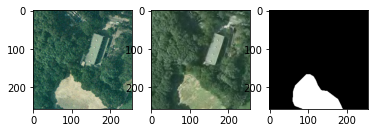

In [3]:
idx = random.randint(0, len(cddata.imgs1)-1)
img1, img2 = cddata.get_img12(idx)
cddata.show_all(idx)

In [171]:
import random
from collections import deque

import cv2
import torch
import torch.nn as nn
import numpy as np
from loguru import logger
from skimage.metrics import structural_similarity
from sklearn.metrics.pairwise import cosine_similarity


from utils import is_gray


class DataMemoryBank(object):
    
    def __init__(self, cap=None, fe=None) -> None:
        super().__init__()
        self.cap = cap
        self.fe = fe
        self.mem = deque([], maxlen=self.cap) # [[img, emb1(ssim), emb2(feature)]]
    
    def clear(self):
        del self.mem
        self.mem = deque([], maxlen=self.cap)
    
    def push(self, samples): # samples [patch1, patch2]
        if not isinstance(samples, list):
            samples = [samples]
        emb1s = self.get_emb(samples, choice='emb1')
        emb2s = self.get_emb(samples, choice='emb2')
        items = [list(item) for item in zip(samples, emb1s, emb2s)]
        self.mem.extend(items)
        return items
        
    def sample_from_memory(self, n=None):
        if n is None:
            samples = self.mem.copy()
        elif n <= len(self.mem):
            samples = random.sample(self.mem, n)
        else:
            logger.warning(f'try sample ({n}) from ({len(self.mem)}). return all')
            samples = self.mem.copy()
        return samples
    
    def get_imgs(self):
        imgs = [i[0] for i in self.mem]
        return imgs
    
    def get_emb(self, samples, choice='emb1'):
        if not isinstance(samples, list):
            samples = [samples]
            
        if choice in ['emb1']: 
            embs = [sample if is_gray(sample) \
                else cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)  for sample in samples]
        elif (choice in ['emb2']):
            if self.fe is None:
                embs = [None for sample in samples]
            else:
                embs = [getattr(self.fe, 'extract_emb', 'forward')(sample)\
                    for sample in samples]
        else:
            raise NotImplementedError(f"wrong: {self.fe}/{choice}")
        return embs
    
    def update_emb2(self): # update all emb2s
        if self.fe is None:
            return
        emb2s = self.get_emb(self.get_imgs(), choice='emb2')
        for idx in range(len(self.mem)):
            self.mem[idx][2] = emb2s[idx]
            
    def update_fe(self, fe):
        self.fe = fe
    
    
    def compare_emb1(self, query, keys, method='ssim'):
        if method == 'ssim':
            h,w = query.shape[:2]
            keys = [cv2.resize(key, (w,h)) for key in keys]
            
            dists = [structural_similarity(query,key,win_size=7) for key in keys]
        return dists
    
    
    def compare_emb2(self, query, keys, method='cos'):
        if method == 'cos':
            if isinstance(list): keys = np.stack(keys, axis=0)
            dists = cosine_similarity(query, keys)
        return dists

    
    def get_pos_neg(self, img, npos=10, nneg=10, base=None, use='emb1', return_img=True, push_img=True):
        samples = self.sample_from_memory(n=base)
        if use == 'emb1':
            query = self.get_emb([img], choice='emb1')[0]
            emb1s = [item[1] for item in samples]
            similars = self.compare_emb1(query, emb1s, method='ssim')

        elif use == 'emb2':
            query = self.get_emb([img], choice='emb2')[0]
            emb2s = [item[2] for item in samples]
            similars = self.compare_emb2(query, emb2s, method='cos')
            
        argsorts = np.argsort(similars).tolist() # small --> large
        pos_idx = random.sample(argsorts[-npos:],1)[0]
        neg_idx = random.sample(argsorts[:nneg],1)[0]
        pos = samples[pos_idx]
        neg = samples[neg_idx]
        
        if push_img:
            self.push([img])
        
        if return_img:
            return pos[0], neg[0]
        else:
            return pos, neg
        
dmb = DataMemoryBank(cap=100, fe=None)

In [172]:
dmb.clear()
for i in range(50):
    idx = random.randint(0, len(cddata.imgs1)-1)
    img1, img2 = cddata.get_img12(idx)
    img = img1.copy() if random.random() < 0.5 else img2.copy()
    bboxes = augops.get_bboxes(nums=10, img_hw=(80,80))
    for (x, y, dx, dy) in bboxes:
        patch = img[x:x+dx, y:y+dy]
        dmb.push(patch)

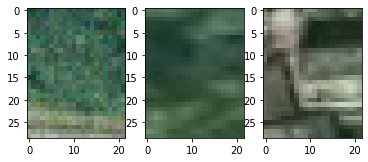

In [261]:
idx = random.randint(0, len(cddata.imgs1)-1)
img1, img2 = cddata.get_img12(idx)
img = img1.copy() if random.random() < 0.5 else img2.copy()
(x, y, dx, dy) = augops.get_bboxes(nums=1, img_hw=(80,80))[0]
patch = img[x:x+dx, y:y+dy]

pos, neg = dmb.get_pos_neg(patch, use='emb1', npos=2, nneg=2)
pos = cv2.resize(pos, (dy,dx))
neg = cv2.resize(neg, (dy,dx))
plt.figure()
plt.subplot(131);plt.imshow(patch)
plt.subplot(132);plt.imshow(pos)
plt.subplot(133);plt.imshow(neg)
plt.show()


## debug


In [ ]:
from collections import deque
import numpy as np
import random

In [ ]:
i1 = [i for i in range(1,10)]
i2 = [i for i in range(11,20)]
i3 = [i for i in range(101,110)]

In [ ]:
a = deque([list(i) for i in zip(i1,i2,i3)], maxlen=10)

In [ ]:
a[5][0] = 101

In [ ]:
a

deque([[1, 11, 101],
       [2, 12, 102],
       [3, 13, 103],
       [4, 14, 104],
       [5, 15, 105],
       [101, 16, 106],
       [7, 17, 107],
       [8, 18, 108],
       [9, 19, 109]])

In [ ]:
b = a.copy()

In [ ]:
a[1] = 10

In [ ]:
a

deque([[1, 11, 101],
       10,
       [3, 13, 103],
       [4, 14, 104],
       [5, 15, 105],
       [101, 16, 106],
       [7, 17, 107],
       [8, 18, 108],
       [9, 19, 109]])

In [ ]:
b

deque([[1, 11, 101],
       [2, 12, 102],
       [3, 13, 103],
       [4, 14, 104],
       [5, 15, 105],
       [101, 16, 106],
       [7, 17, 107],
       [8, 18, 108],
       [9, 19, 109]])